# XGBoost — Extreme Gradient Boosting

**Learning Objectives:**
- Understand gradient boosting: sequential trees that correct residual errors
- Train and interpret sklearn's `GradientBoostingClassifier` with tuned parameters
- Visualize the learning curve (loss vs boosting rounds) to diagnose overfitting
- Compare `GradientBoostingClassifier` vs `XGBClassifier`

**Dataset:** Lending Club (credit card default prediction)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb

seed = 42

If xgboost is not installed: `pip install xgboost`

In [2]:
df = pd.read_csv('data/lending_data.csv')
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
df.drop('ID', axis=1, inplace=True)

target_col = 'default.payment.next.month'
print(f'Target distribution:')
print(df[target_col].value_counts())
print(f'\nDataset shape: {df.shape}')

Target distribution:
default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

Dataset shape: (30000, 24)


In [4]:
X = df.drop(target_col, axis=1)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=y
)

X_train_fit, X_val, y_train_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=seed, stratify=y_train
)

print(f'Train: {X_train_fit.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Train: (19200, 23), Val: (4800, 23), Test: (6000, 23)


### How Gradient Boosting Works

Gradient boosting builds an ensemble of **shallow decision trees** sequentially. Unlike Random Forest (which trains trees independently in parallel), each new tree in gradient boosting is trained to correct the **errors** of the previous ensemble.

**Algorithm (simplified):**

1. Start with a constant prediction $F_0(x) = \arg\min_\gamma \sum_i L(y_i, \gamma)$ (e.g., log-odds for classification)
2. For round $m = 1$ to $M$:
   - Compute pseudo-residuals: $r_{im} = -\left[\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}\right]_{F=F_{m-1}}$
     — these are the **negative gradients** of the loss function at the current prediction
   - Fit a regression tree $h_m(x)$ to predict those residuals
   - Update: $F_m(x) = F_{m-1}(x) + \nu \cdot h_m(x)$ where $\nu$ is the **learning rate**

**Key properties:**
- Boosting reduces **bias** (each tree improves on residual errors), while bagging reduces **variance**
- Trees in boosting are typically **shallow** (depth 2–5) — weak learners that avoid overfitting
- The learning rate $\nu$ controls how much each tree contributes — lower $\nu$ needs more trees but generalizes better

### GradientBoostingClassifier — Default

In [5]:
gb_default = GradientBoostingClassifier(random_state=seed)
gb_default.fit(X_train_fit, y_train_fit)
y_pred_gb = gb_default.predict(X_test)

print(f'GradientBoostingClassifier (default):')
print(f'  Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred_gb):.4f}')
print(f'  Recall: {recall_score(y_test, y_pred_gb):.4f}')
print(f'  F1: {f1_score(y_test, y_pred_gb):.4f}')

GradientBoostingClassifier (default):
  Accuracy: 0.8190
  Precision: 0.6653
  Recall: 0.3655
  F1: 0.4718


### Learning Curve — Loss vs Boosting Rounds

`staged_decision_function()` returns predictions after each boosting round. We can track train/validation loss across rounds to find the optimal number of trees and detect overfitting.

In [ ]:
train_loss = []
val_loss = []

for y_pred_train_staged in gb_default.staged_decision_function(X_train_fit):       ###### This gets us  the raw scores (residuals or log-odds in this case) for each stage of the boosting process.
    probas = 1 / (1 + np.exp(-y_pred_train_staged))
    train_loss.append(log_loss(y_train_fit, np.column_stack([1 - probas, probas])))    ###### Here we apply our loss function across the training data for each stage, using the predicted probabilities derived from the raw scores.
                                                                                        ###### in this case, classification, we need to convert the raw scores to probabilities using the logistic function (sigmoid) before calculating the log loss.

for y_pred_val_staged in gb_default.staged_decision_function(X_val):
    probas = 1 / (1 + np.exp(-y_pred_val_staged))
    val_loss.append(log_loss(y_val, np.column_stack([1 - probas, probas])))

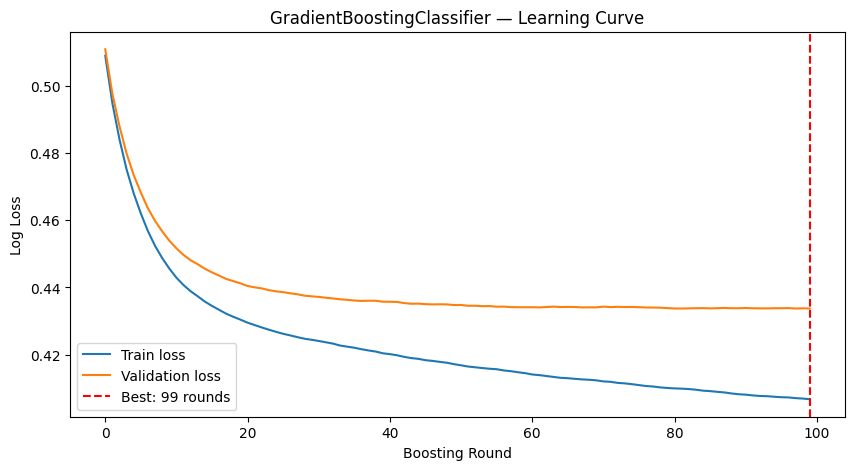

Optimal n_estimators (val): 99


In [7]:
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Train loss')
plt.plot(val_loss, label='Validation loss')
plt.axvline(x=np.argmin(val_loss), color='r', linestyle='--',
            label=f'Best: {np.argmin(val_loss)} rounds')
plt.xlabel('Boosting Round')
plt.ylabel('Log Loss')
plt.title('GradientBoostingClassifier — Learning Curve')
plt.legend()
plt.show()

print(f'Optimal n_estimators (val): {np.argmin(val_loss)}')

### GradientBoostingClassifier — Tuned Parameters

Based on the learning curve, we set `n_estimators` near the optimal point and add regularization.

In [8]:
gb_tuned = GradientBoostingClassifier(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=seed
)
gb_tuned.fit(X_train_fit, y_train_fit)
y_pred_gb_tuned = gb_tuned.predict(X_test)

print(f'GradientBoostingClassifier (tuned):')
print(f'  Accuracy: {accuracy_score(y_test, y_pred_gb_tuned):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred_gb_tuned):.4f}')
print(f'  Recall: {recall_score(y_test, y_pred_gb_tuned):.4f}')
print(f'  F1: {f1_score(y_test, y_pred_gb_tuned):.4f}')

GradientBoostingClassifier (tuned):
  Accuracy: 0.8170
  Precision: 0.6615
  Recall: 0.3534
  F1: 0.4607


### Parameter Notes — GradientBoostingClassifier

| Parameter | Default | Description | Typical Range |
|-----------|---------|-------------|---------------|
| `n_estimators` | 100 | Number of boosting stages. More → lower bias but risk of overfitting. | 50–1000+ |
| `learning_rate` | 0.1 | Shrinkage factor. Lower → need more trees but generalize better. | 0.01–0.3 |
| `max_depth` | 3 | Tree depth. Shallow (2–5) typical for boosting; deeper → overfit. | 2–8 |
| `min_samples_split` | 2 | Min samples to split a node. Higher → simpler trees. | 2–50 |
| `min_samples_leaf` | 1 | Min samples per leaf. Higher → smoother, less overfitting. | 1–20 |
| `max_features` | None | Fraction of features per split. `'sqrt'` or `'log2'` adds randomness. | None, 'sqrt', 'log2' |
| `subsample` | 1.0 | Fraction of samples per boosting round. < 1 → stochastic GBM. | 0.5–1.0 |
| `loss` | `'log_loss'` | Loss function. `'log_loss'` for classification, `'exponential'` for AdaBoost. | log_loss, exponential |
| `criterion` | `'friedman_mse'` | Split quality metric. | friedman_mse, squared_error |
| `validation_fraction` | 0.1 | Fraction for early stopping validation (if `n_iter_no_change` set). | 0.1–0.2 |
| `n_iter_no_change` | None | Stop if validation loss doesn't improve for N rounds. | 5–20 |
| `tol` | 1e-4 | Tolerance for early stopping. | 1e-4–1e-3 |

**Key trade-offs:**
- `learning_rate` ↓ + `n_estimators` ↑: more robust but slower
- `max_depth` ↓ + `subsample` ↓: more conservative, less overfitting
- `min_samples_leaf` ↑: smoother trees, better generalization

### Feature Importance — GradientBoostingClassifier

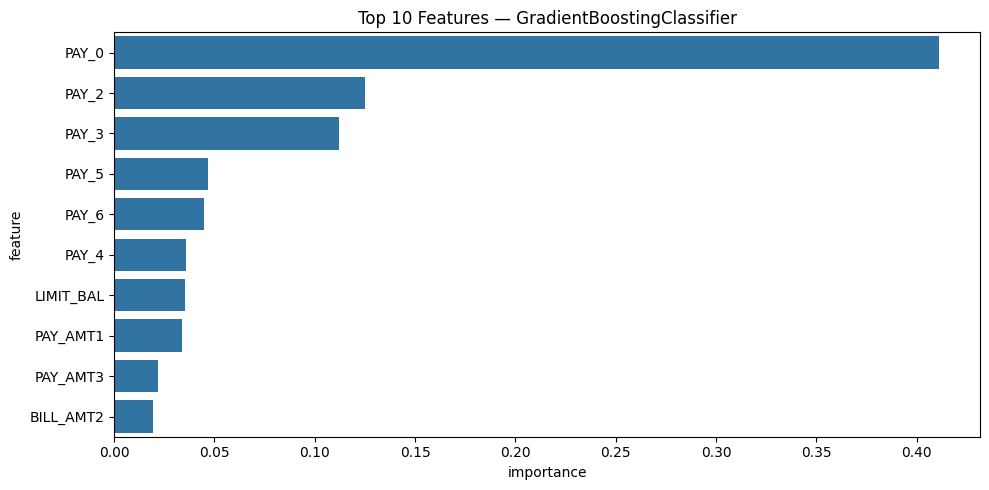

In [9]:
importances_gb = pd.DataFrame({
    'feature': X.columns,
    'importance': gb_tuned.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=importances_gb.head(10), x='importance', y='feature')
plt.title('Top 10 Features — GradientBoostingClassifier')
plt.tight_layout()
plt.show()

### XGBoost — Default Parameters

XGBoost is an optimized gradient boosting library with built-in regularization, parallel processing, sparsity awareness, and more robust early stopping.

In [10]:
xgb_clf = xgb.XGBClassifier(random_state=seed, eval_metric='logloss')
xgb_clf.fit(X_train_fit, y_train_fit)
y_pred_xgb = xgb_clf.predict(X_test)

print(f'XGBoost (default):')
print(f'  Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred_xgb):.4f}')
print(f'  Recall: {recall_score(y_test, y_pred_xgb):.4f}')
print(f'  F1: {f1_score(y_test, y_pred_xgb):.4f}')

XGBoost (default):
  Accuracy: 0.8115
  Precision: 0.6293
  Recall: 0.3595
  F1: 0.4576


### XGBoost — Parameter Deep Dive

#### Core Parameters
- **`n_estimators`** (default 100): Number of boosting rounds. More trees → better fit but risk of overfitting.
- **`max_depth`** (default 6): Maximum tree depth. Deeper → more complex interactions but overfit faster. Typical range: 3–10.
- **`learning_rate`** (eta, default 0.3): Shrinkage step size. Lower → more robust but needs more trees.

#### Regularization (Tree Structure)
- **`gamma`** (min_split_loss, default 0): Minimum loss reduction to make a split. Higher → fewer splits, simpler trees.
- **`subsample`** (default 1.0): Row sampling per round. < 1 → stochastic boosting, reduces overfitting.
- **`colsample_bytree`** (default 1.0): Column sampling per tree. Similar to RF's `max_features`.
- **`colsample_bylevel`** (default 1.0): Column sampling per tree level.

#### Regularization (Leaf Weights)
- **`reg_alpha`** (L1, default 0): L1 regularization on leaf weights. Encourages sparsity.
- **`reg_lambda`** (L2, default 1): L2 regularization on leaf weights. Reduces overfitting.

#### Practical Training
- **`early_stopping_rounds`** (default None): Stop if validation metric doesn't improve for N rounds.
- **`eval_metric`**: Metric for validation data. Common: `'logloss'`, `'auc'`, `'error'`.
- **`scale_pos_weight`** (default 1): Weight positive class. Typically `sum(neg) / sum(pos)` for imbalanced data.

### XGBoost — Tuned + Early Stopping

In [11]:
xgb_tuned = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='logloss',
    early_stopping_rounds=20,
    random_state=seed
)

xgb_tuned.fit(
    X_train_fit, y_train_fit,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f'Best iteration: {xgb_tuned.best_iteration}')

y_pred_tuned = xgb_tuned.predict(X_test)
print(f'XGBoost (tuned):')
print(f'  Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred_tuned):.4f}')
print(f'  Recall: {recall_score(y_test, y_pred_tuned):.4f}')
print(f'  F1: {f1_score(y_test, y_pred_tuned):.4f}')

Best iteration: 151
XGBoost (tuned):
  Accuracy: 0.8188
  Precision: 0.6667
  Recall: 0.3617
  F1: 0.4690


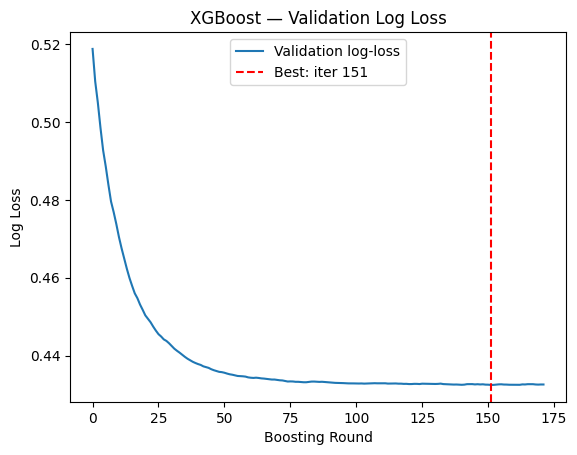

In [12]:
results = xgb_tuned.evals_result()
plt.plot(results['validation_0']['logloss'], label='Validation log-loss')
plt.xlabel('Boosting Round')
plt.ylabel('Log Loss')
plt.title('XGBoost — Validation Log Loss')
plt.axvline(x=xgb_tuned.best_iteration, color='r', linestyle='--',
            label=f'Best: iter {xgb_tuned.best_iteration}')
plt.legend()
plt.show()

### Feature Importance — XGBoost

Three importance types:
- **weight**: number of times a feature is used to split
- **gain**: average information gain when used for splitting
- **cover**: average number of samples affected

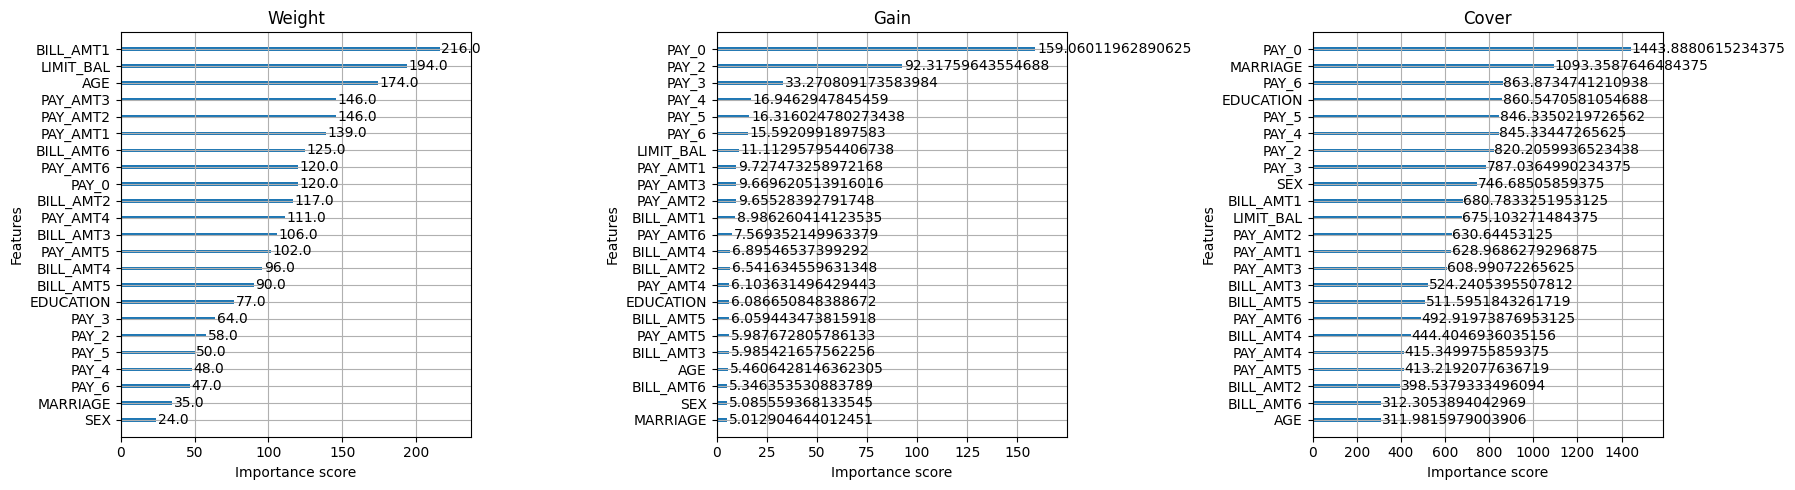

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

xgb.plot_importance(xgb_tuned, importance_type='weight', ax=axes[0], title='Weight')
xgb.plot_importance(xgb_tuned, importance_type='gain', ax=axes[1], title='Gain')
xgb.plot_importance(xgb_tuned, importance_type='cover', ax=axes[2], title='Cover')

plt.tight_layout()
plt.show()

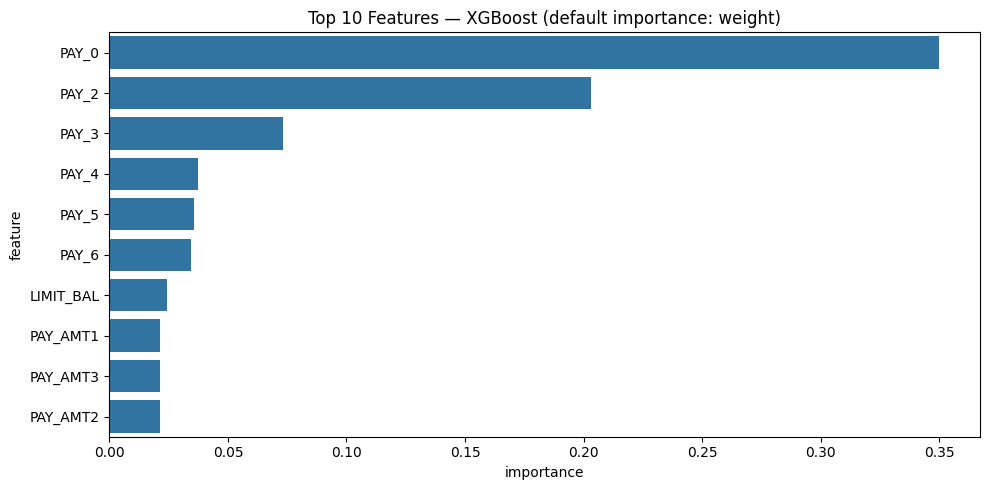

In [ ]:
importances_xgb = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_tuned.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=importances_xgb.head(10), x='importance', y='feature') # importance_type is "weight" if booster == "gblinear" else "gain"
plt.title('Top 10 Features — XGBoost (default importance: weight)')
plt.tight_layout()
plt.show()

### Comparison: GBC vs XGBoost

| Aspect | GradientBoostingClassifier | XGBClassifier |
|--------|---------------------------|---------------|
| **Implementation** | Pure Python/scikit-learn | C++ with Python bindings (optimized) |
| **Speed** | Slower for large datasets | ~10x faster (parallel processing, cache-aware) |
| **Regularization** | Limited (depth, subsample, min_samples) | Rich (gamma, reg_alpha, reg_lambda, colsample_by*) |
| **Missing values** | Must impute beforehand | Built-in sparsity awareness (learns default direction) |
| **Early stopping** | Via `n_iter_no_change` | Via `early_stopping_rounds` + `eval_set` |
| **Default tree depth** | 3 (shallow, boosting-friendly) | 6 (deeper, may need tuning) |
| **Scalability** | Good for small-medium data | Excellent for large-scale data |

### Parameter Notes — XGBClassifier

| Parameter | Default | Description | Typical Range |
|-----------|---------|-------------|---------------|
| `n_estimators` | 100 | Number of boosting rounds | 100–1000+ |
| `max_depth` | 6 | Max tree depth | 3–10 |
| `learning_rate` | 0.3 | Shrinkage step size (eta) | 0.01–0.3 |
| `subsample` | 1.0 | Row sampling fraction per round | 0.5–1.0 |
| `colsample_bytree` | 1.0 | Column sampling per tree | 0.3–1.0 |
| `gamma` | 0 | Min loss reduction for split | 0–5 |
| `reg_alpha` | 0 | L1 regularization on weights | 0–10 |
| `reg_lambda` | 1 | L2 regularization on weights | 0–10 |
| `scale_pos_weight` | 1 | Balance class weights | sum(neg)/sum(pos) |
| `eval_metric` | — | Validation metric | logloss, auc, error |
| `early_stopping_rounds` | None | Stop when no improvement | 10–50 |

**Key relationships:**
- `learning_rate` ↓ + `n_estimators` ↑ → better generalization but slower training
- `max_depth` ↓ + `subsample` ↓ → more conservative, less overfitting
- `reg_alpha` / `reg_lambda` ↑ → stronger regularization

## Exercises

1. Train `GradientBoostingClassifier(max_depth=2, learning_rate=0.2)`. How do the learning curve and metrics change?
2. Re-run the XGBoost staged loss plot. At which round does validation loss start increasing?
3. Apply XGBoost to the `sonar_data.csv` dataset. Compare accuracy with `GradientBoostingClassifier`.
4. Use `importance_type='gain'` in XGBoost and identify the top 3 features for the lending dataset.

In [15]:
# TODO: Complete the exercises